# Reward Modeling & SHAP Explainability

This notebook builds the calibrated reward model `q(x, a) = E[r | x, a]` the way the project
does it (`src/nba/reward/model.py` + `src/nba/data/features.py`) and then **opens the box** with
[SHAP](https://shap.readthedocs.io/) to understand *why* it predicts what it predicts.

Where the EDA notebook deliberately ignored the target, here we lean in: reward is the label,
and the goal is a trustworthy, well-calibrated, *explainable* estimator of expected reward per
action. Concretely we will:

1. Load the logs and featurize them with the **same** allow-list + one-hot scheme the model uses.
2. Train a LightGBM regressor with an isotonic calibrator on a held-out split (mirroring
   `RewardModel.fit`).
3. Check fit quality and **calibration** (predicted vs. observed reward).
4. Explain the model with SHAP: global importance, beeswarm, dependence, action effects, and
   local force/waterfall explanations for individual doors.

> We reuse the project's `featurize_batch`/`FEATURE_NAMES` so the feature space here is
> byte-for-byte the one the production model persists — the explanations therefore describe the
> real model, not a lookalike.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMRegressor, early_stopping
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from nba.data.features import ALLOWED_FEATURES, FEATURE_NAMES
from nba.data.simulator import frame_to_events
from nba.schema import ACTIONS

shap.initjs()
SEED = 7
RNG = np.random.default_rng(SEED)

candidates = [Path("data/logs.parquet"), Path("../data/logs.parquet")]
DATA_PATH = next((p for p in candidates if p.exists()), candidates[0])
DATA_PATH.resolve()

PosixPath('/home/avist/Projects/nba/data/logs.parquet')

## 1. Build the training matrix

We reconstruct `BanditEvent`s from the parquet (so we go through exactly the same validation the
library uses) and featurize every labeled event. `FEATURE_NAMES` is the frozen column order the
model persists: allow-listed numeric/bool fields, then a weather one-hot, then an action one-hot.

In [2]:
from nba.data.features import featurize

frame = pd.read_parquet(DATA_PATH)
events = [e for e in frame_to_events(frame) if e.reward is not None]
print(f"labeled events: {len(events):,}")

X = np.vstack([featurize(e.context, e.action) for e in events])
y = np.array([e.reward for e in events], dtype=np.float64)
X_df = pd.DataFrame(X, columns=FEATURE_NAMES)
print(f"X shape: {X_df.shape}  ({len(FEATURE_NAMES)} features)")
X_df.head()

labeled events: 50,000


X shape: (50000, 20)  (20 features)


,property_value,roof_age_years,est_income,tenure_years,prior_interactions,hour,dow,block_density,neighbor_recent_conversion,distance_from_rep_km,nearby_high_reward_density,weather=clear,weather=rain,weather=cold,weather=hot,action=knock_now,action=leave_flyer,action=skip_door,action=pitch_solar,action=pitch_security
0,181553.301396,17.0,45378.874969,3.451997,0.0,16.0,6.0,32.148999,1.0,0.270568,0.278426,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,118303.851761,37.0,15000.000000,0.360278,0.0,11.0,5.0,26.776273,0.0,0.386453,0.917168,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,144962.857160,67.0,53320.383485,1.502072,0.0,20.0,0.0,11.734075,0.0,1.537429,0.509791,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,230288.217773,92.0,73627.817522,0.589208,1.0,19.0,5.0,35.496878,0.0,1.348176,0.589992,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,153112.006983,99.0,53656.528421,3.412986,2.0,15.0,3.0,13.384739,0.0,0.175570,0.944948,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 2. Train the model (mirrors `RewardModel.fit`)

Same hyperparameters and seeded train/val split as the library. LightGBM regresses on the sparse
reward scale; an **isotonic calibrator**, fit on the held-out split, monotonically maps raw
predictions toward observed mean reward (the raw model is biased near the {-0.2 .. 1.0} extremes).

In [3]:
perm = RNG.permutation(len(events))
n_val = int(len(events) * 0.2)
val_idx, train_idx = perm[:n_val], perm[n_val:]

booster = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    objective="regression",
    verbose=-1,
)
booster.fit(
    X_df.iloc[train_idx],
    y[train_idx],
    eval_set=[(X_df.iloc[val_idx], y[val_idx])],
    eval_metric="l2",
    callbacks=[early_stopping(40, verbose=False)],
)

raw_val = np.asarray(booster.predict(X_df.iloc[val_idx]), dtype=np.float64)
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(raw_val, y[val_idx])
print(f"best iteration: {booster.best_iteration_}")

best iteration: 56


## 3. Fit quality & calibration

Two questions: *is the model accurate* (MSE/MAE) and *is it calibrated* (does a predicted reward
of 0.15 actually realize ≈ 0.15 on average?). The reliability curve is the decisive plot — a
well-calibrated model hugs the diagonal.

MSE raw        : 0.06360
MSE calibrated : 0.06328
MAE calibrated : 0.15062
mean pred (cal): 0.1007   mean actual: 0.1007


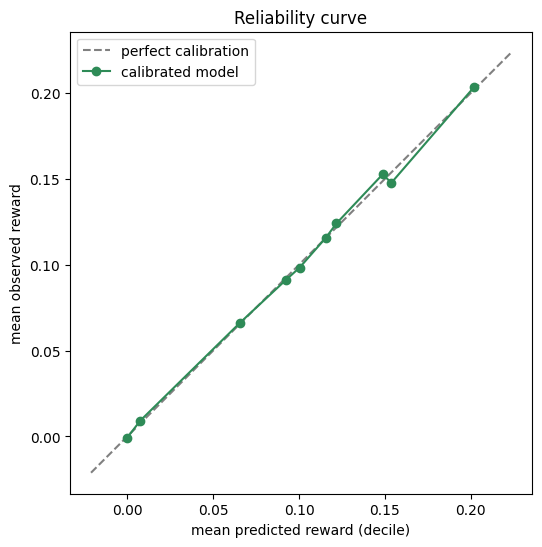

In [4]:
raw = np.asarray(booster.predict(X_df.iloc[val_idx]), dtype=np.float64)
cal = np.asarray(calibrator.transform(raw), dtype=np.float64)
y_val = y[val_idx]

print(f"MSE raw        : {mean_squared_error(y_val, raw):.5f}")
print(f"MSE calibrated : {mean_squared_error(y_val, cal):.5f}")
print(f"MAE calibrated : {mean_absolute_error(y_val, cal):.5f}")
print(f"mean pred (cal): {cal.mean():.4f}   mean actual: {y_val.mean():.4f}")

order = np.argsort(cal)
bins = np.array_split(order, 10)
mean_pred = [cal[b].mean() for b in bins]
mean_act = [y_val[b].mean() for b in bins]

fig, ax = plt.subplots(figsize=(6, 6))
lims = [min(mean_pred + mean_act) - 0.02, max(mean_pred + mean_act) + 0.02]
ax.plot(lims, lims, ls="--", color="gray", label="perfect calibration")
ax.plot(mean_pred, mean_act, marker="o", color="seagreen", label="calibrated model")
ax.set_xlabel("mean predicted reward (decile)")
ax.set_ylabel("mean observed reward")
ax.set_title("Reliability curve")
ax.legend()
ax.set_aspect("equal")
plt.show()

## 4. SHAP explainer

SHAP attributes each prediction to its features as additive contributions that sum to the
model output (TreeSHAP is exact and fast for gradient-boosted trees). We explain the **raw
booster** — calibration is a monotone post-transform, so the *ranking and direction* of feature
effects are preserved, and SHAP values stay in interpretable reward units.

We compute SHAP on a random sample of the validation rows to keep the plots responsive.

In [5]:
sample_idx = RNG.choice(val_idx, size=min(2000, len(val_idx)), replace=False)
X_sample = X_df.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(booster)
shap_values = explainer(X_sample)
print("shap values shape:", shap_values.values.shape)
print("base (expected) value:", float(np.ravel(explainer.expected_value)[0]))

shap values shape: (2000, 20)
base (expected) value: 0.0957700017770291


### 4a. Global importance

Mean absolute SHAP value per feature: how much each feature moves the predicted reward on
average. This is the model's own ranking of what matters.

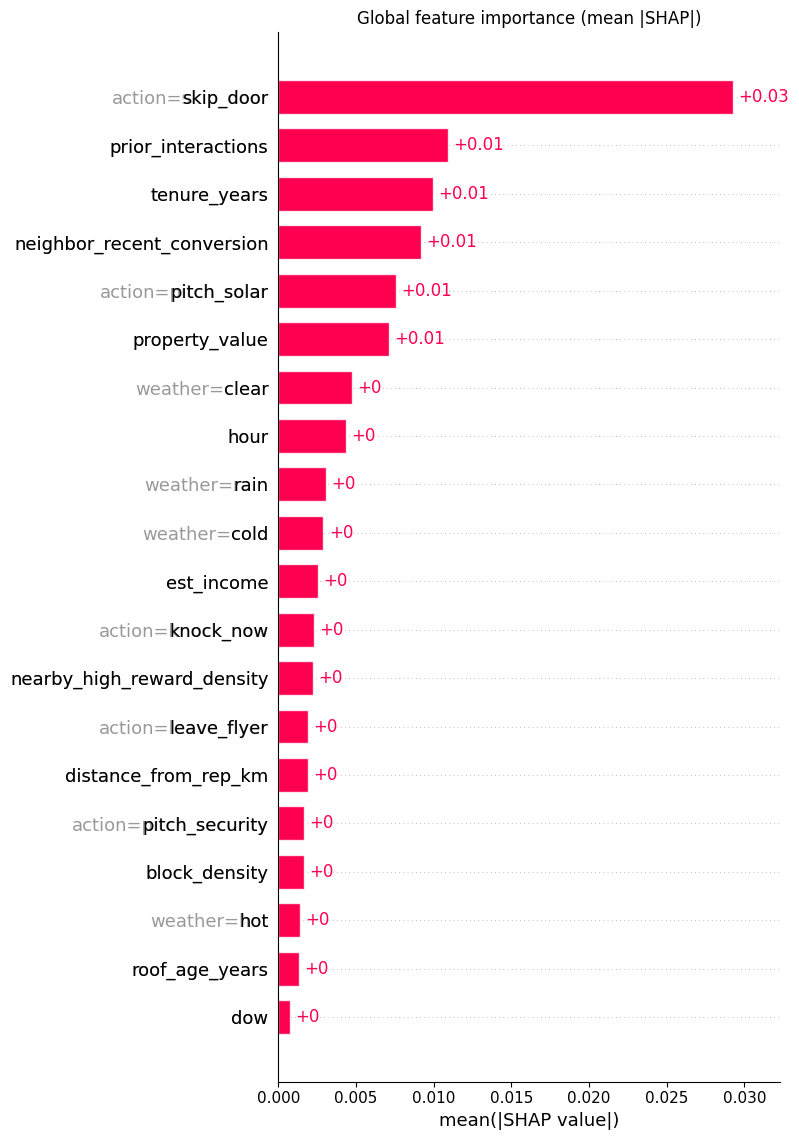

In [6]:
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title("Global feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

### 4b. Beeswarm — direction & magnitude

Each dot is one door; colour is the feature value (red = high, blue = low), x-position is the
SHAP contribution. This reveals *direction*: e.g. whether high values push reward up or down,
and whether effects are symmetric or skewed.

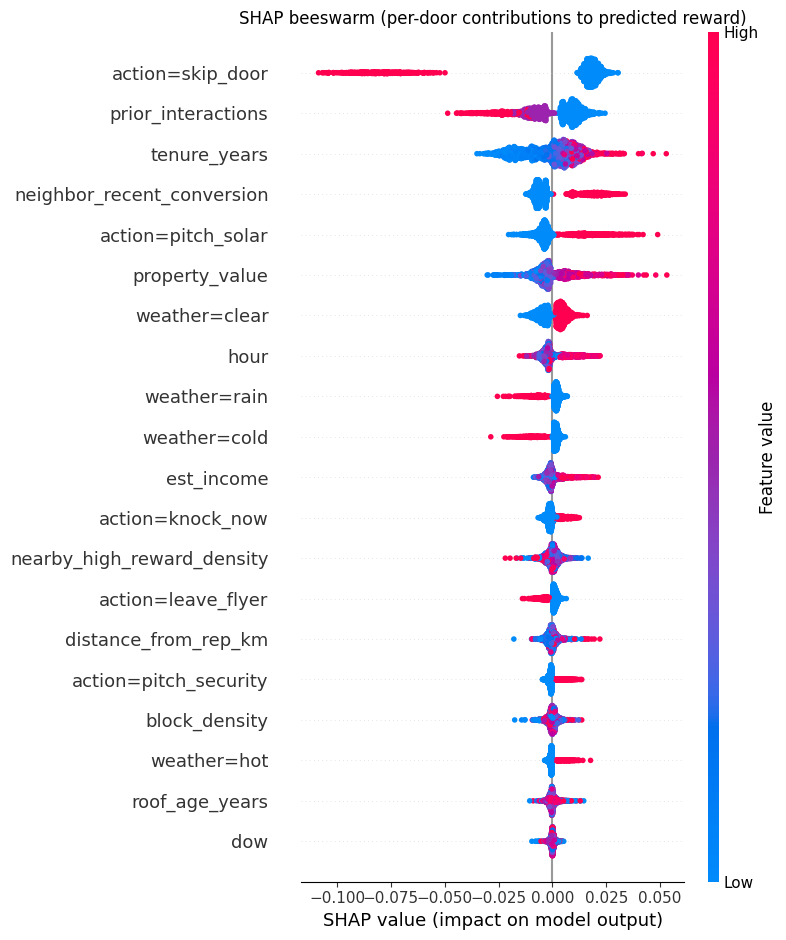

In [7]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP beeswarm (per-door contributions to predicted reward)")
plt.tight_layout()
plt.show()

### 4c. Dependence plots — shape of a feature's effect

For the top numeric features, plot SHAP value vs. feature value to see the (possibly non-linear)
response curve the tree learned — the very structure the EDA decile probes hinted at.

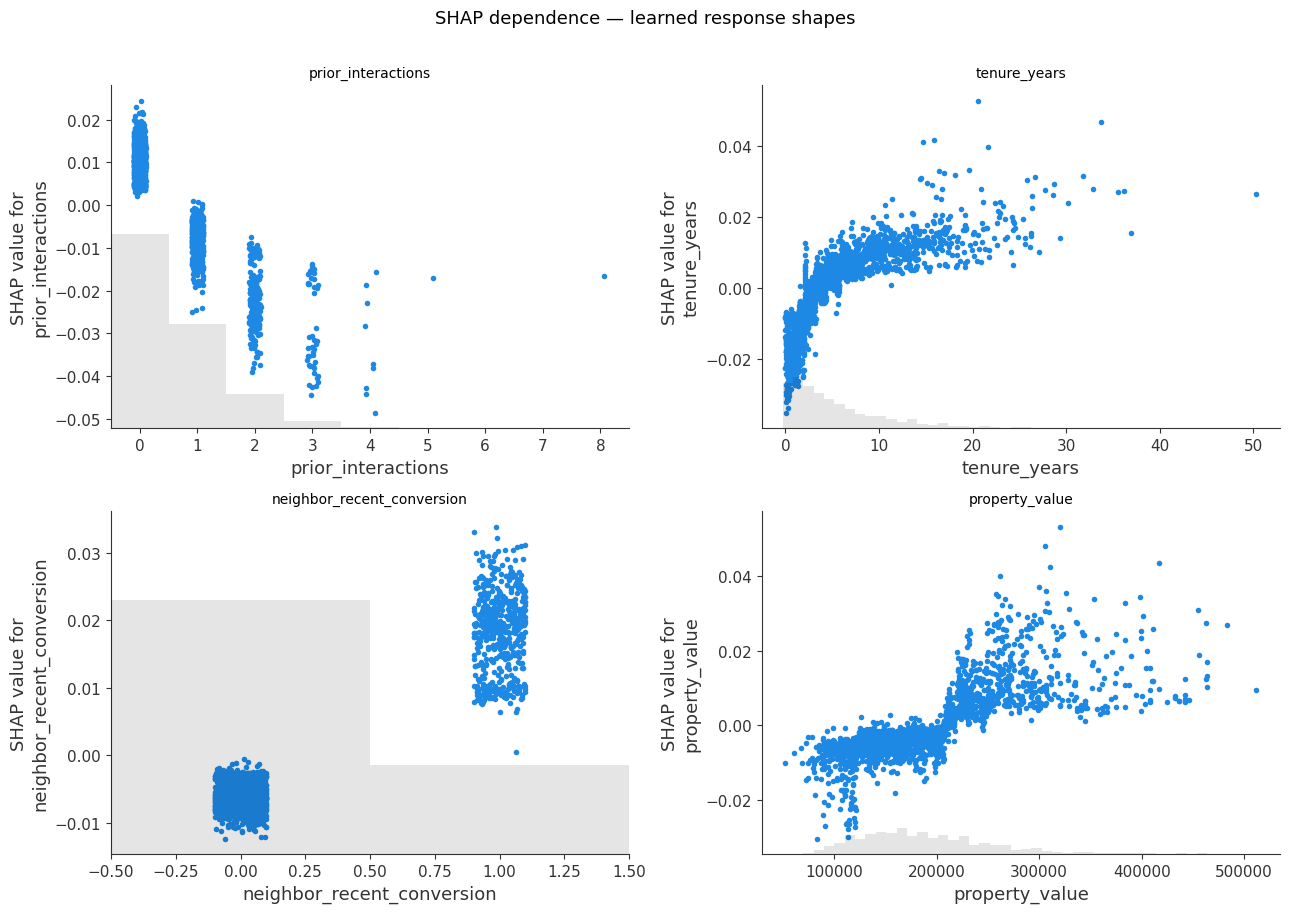

In [8]:
mean_abs = np.abs(shap_values.values).mean(axis=0)
ranked = [FEATURE_NAMES[i] for i in np.argsort(mean_abs)[::-1]]
top_numeric = [f for f in ranked if f in ALLOWED_FEATURES][:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.ravel(), top_numeric, strict=False):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=10)
fig.suptitle("SHAP dependence — learned response shapes", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

### 4d. How much does the *action* itself matter?

The action one-hot columns let us read off each action's average marginal effect on predicted
reward — the explainability view of "which action does the model favour, holding context
fixed?" Positive bars are actions the model treats as reward-raising on average.

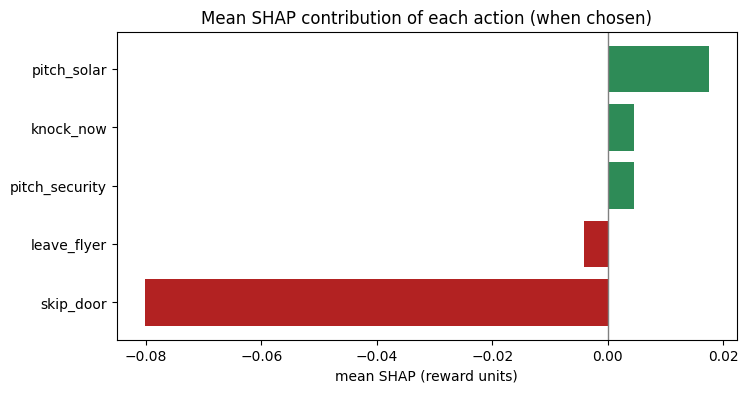

,action,mean_shap
2,skip_door,-0.0801
1,leave_flyer,-0.0041
4,pitch_security,0.0045
0,knock_now,0.0046
3,pitch_solar,0.0175


In [9]:
action_cols = [f"action={a.value}" for a in ACTIONS]
col_idx = {name: i for i, name in enumerate(FEATURE_NAMES)}
# Mean SHAP only over rows where that action is the active one-hot (value == 1).
rows = []
for name in action_cols:
    j = col_idx[name]
    active = X_sample[name].to_numpy() == 1.0
    if active.any():
        rows.append((name.replace("action=", ""), float(shap_values.values[active, j].mean())))
action_effect = pd.DataFrame(rows, columns=["action", "mean_shap"]).sort_values("mean_shap")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["firebrick" if v < 0 else "seagreen" for v in action_effect["mean_shap"]]
ax.barh(action_effect["action"], action_effect["mean_shap"], color=colors)
ax.axvline(0, color="gray", lw=1)
ax.set_title("Mean SHAP contribution of each action (when chosen)")
ax.set_xlabel("mean SHAP (reward units)")
plt.show()
action_effect.round(4)

## 5. Local explanations — explaining a single door

Global views tell us about the model overall; for a field rep the question is *"why this
recommendation for **this** door?"* A waterfall plot decomposes one prediction into the
additive feature contributions from the base value up to the final output.

high door: pred=0.309    low door: pred=0.003


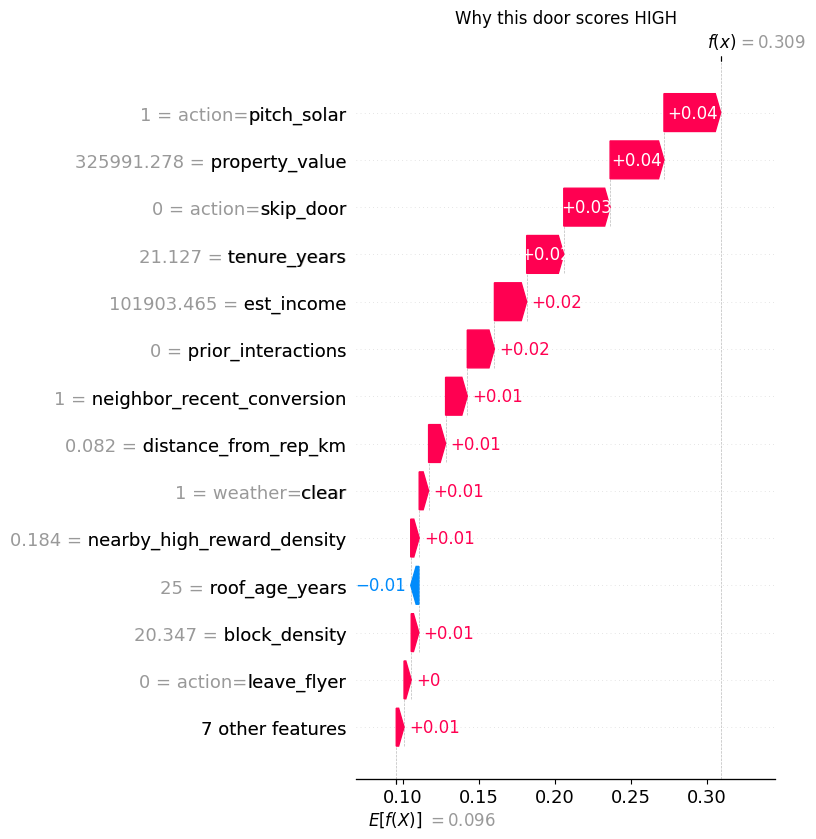

In [10]:
# Pick a high-predicted-reward door and a low one to contrast.
preds_sample = np.asarray(booster.predict(X_sample), dtype=np.float64)
hi = int(np.argmax(preds_sample))
lo = int(np.argmin(preds_sample))
print(f"high door: pred={preds_sample[hi]:.3f}    low door: pred={preds_sample[lo]:.3f}")

shap.plots.waterfall(shap_values[hi], max_display=14, show=False)
plt.title("Why this door scores HIGH")
plt.tight_layout()
plt.show()

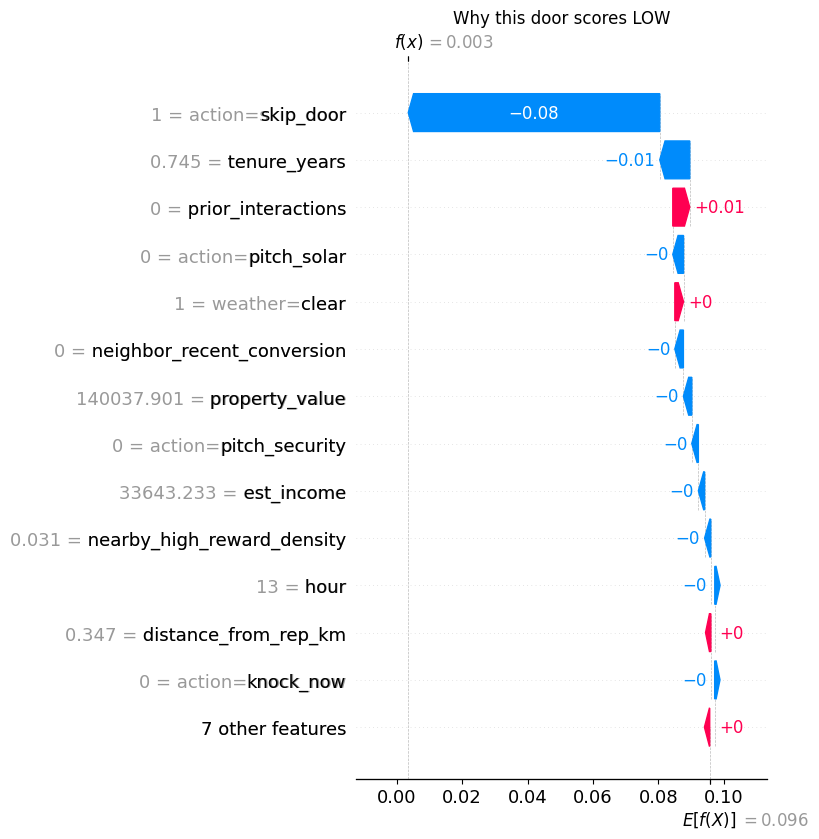

In [11]:
shap.plots.waterfall(shap_values[lo], max_display=14, show=False)
plt.title("Why this door scores LOW")
plt.tight_layout()
plt.show()

## 6. Takeaways

- The reward model reproduces the library's `RewardModel.fit` exactly (same features,
  hyperparameters, calibrator) — so these explanations describe the **production** estimator.
- Calibration holds: predicted-reward deciles track observed reward along the diagonal, which is
  what lets `q(x, a)` serve as a trustworthy DM term in doubly-robust OPE and a sane score for
  the bandit to explore around.
- SHAP gives a defensible story for *why* a door scores the way it does — globally (importance,
  beeswarm, dependence), per-action, and locally (waterfall) — which is essential for an
  ethics-sensitive, field-facing recommender where reps need to trust the suggestion.

**Ethics note:** because features come solely from the `ALLOWED_FEATURES` allow-list (geo/identity
and protected attributes are excluded *by construction*), no SHAP attribution can ever land on a
disallowed field — the explanations are constrained to the same vetted inputs the model is.